# Omega60 laser sampling

In [ ]:
import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import uniform
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pandas as pd
import pyvista as pv
from scipy.stats import norm
import scipy.stats as stats 


     ---------------------------------------- 0.0/41.4 kB ? eta -:--:--
     ---------------------------------------- 41.4/41.4 kB 2.1 MB/s eta 0:00:00
     ---------------------------------------- 0.0/82.2 kB ? eta -:--:--
     ---------------------------------------- 82.2/82.2 kB 2.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/5.1 MB ? eta -:--:--
   - -------------------------------------- 0.2/5.1 MB 5.3 MB/s eta 0:00:01
   --- ------------------------------------ 0.4/5.1 MB 4.1 MB/s eta 0:00:02
   ----- ---------------------------------- 0.7/5.1 MB 4.6 MB/s eta 0:00:01
   ------ --------------------------------- 0.9/5.1 MB 5.1 MB/s eta 0:00:01
   ------- -------------------------------- 1.0/5.1 MB 5.0 MB/s eta 0:00:01
   --------- ------------------------------ 1.2/5.1 MB 4.8 MB/s eta 0:00:01
   ----------- ---------------------------- 1.5/5.1 MB 4.9 MB/s eta 0:00:01
   ------------- -------------------------- 1.7/5.1 MB 4.9 MB/s eta 0:00:01
   -------------- -


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\clara\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Support functions

### Conversion

In [514]:
def sph_to_cart(r, theta, phi):
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    return np.array([x, y, z])

def cart_to_sph(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(z / r)
    phi = np.pi + np.arctan2(y, x)
    return np.array([r, theta, phi])

### Spherical function plotter

In [515]:
def plot_spherical_function(theta, phi, f, name='f', title="Spherical Function"):
  f_flat = f.ravel()

  xs, ys, zs = sph_to_cart(1.0, theta, phi)
  points = np.column_stack((xs.ravel(), ys.ravel(), zs.ravel()))
  f_flat = f.ravel()

  cloud = pv.PolyData(points)
  cloud[name] = f_flat

  plotter = pv.Plotter()
  plotter.add_mesh(cloud, render_points_as_spheres=True, point_size=10, scalars=name, cmap='plasma')
  plotter.add_scalar_bar(title=name, vertical=True)

  return plotter

### Plotter of sectors given theta and phi

In [516]:
def plot_spherical_sectors( theta, phi, fs, name='func', title="Spherical Sectors" ):

  func = sp.interpolate.RegularGridInterpolator( (theta, phi), fs, method='nearest', bounds_error=False, fill_value=0.0 )

  sphere = pv.Sphere( theta_resolution=100, phi_resolution=100 )
  r, ts, ps = cart_to_sph( sphere.points[:,0], sphere.points[:,1], sphere.points[:,2] )
  sphere['Data'] = func( ( ts, ps, ) )

  plotter = pv.Plotter()
  plotter.add_mesh(sphere, scalar_bar_args={'title': 'Z Position'})
  
  return plotter

### Sample of random laser points in a 2D window distribution normale

In [517]:
def sample_window( t1, t2, l1=1., l2=1., center=np.array([ 0., 0., 0., ]), num_points=1000, dist = lambda num_points: sp.stats.uniform.rvs( loc=-1.0, scale=2.0, size=( num_points, 2, ) ), ):
  # sample distribution 
  sample = np.zeros( (num_points, 2,) )
  k = 0
  while k < num_points:
    s = dist(1)
    if np.abs(s[0,0]) <= 1.0 and np.abs(s[0,1]) <= 1.0:
      sample[k,:] = s[0,:]
      k += 1
  # map to the window
  v1 = 0.5 * l1 * t1 / np.linalg.norm( t1 )
  v2 = 0.5 * l2 * t2 / np.linalg.norm( t2 )
  return center + sample[:,0,None] * v1 + sample[:,1,None] * v2

In [518]:
t1 = np.array([ 0., 1., 0., ]) # ey
t2 = np.array([ 0., 0., 1., ]) # ez

xs = sample_window( t1, t2, l1=2., l2=2., center=np.array([ 0., 0., 0., ]), num_points=1000, )

focus = np.array([ 1., 0., 0., ])
us = focus - xs
us = us / np.linalg.norm( us, axis=1 )[:,None]

print(xs.shape)

(1000, 3)


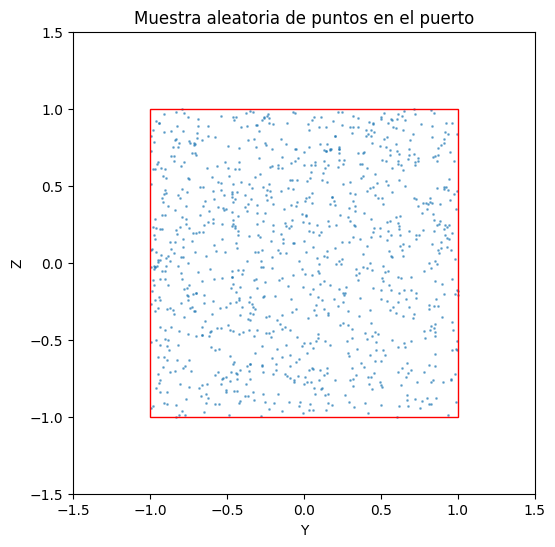

In [519]:
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter( xs[:,1], xs[:,2], s=1, alpha=0.5 )

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

ax.set_title("Muestra aleatoria de puntos en el puerto")
ax.set_xlabel("Y")
ax.set_ylabel("Z")

rect = plt.Rectangle( (-1,-1), 2, 2, linewidth=1, edgecolor='r', facecolor='none' )
ax.add_patch(rect)

### Use of normal distribution in the sample of points distribution Gaussienne

In [520]:
dist = lambda num_points: sp.stats.norm(loc=0.0, scale=0.5).rvs(size=(num_points, 2))
xs = sample_window( t1, t2, l1=2., l2=2., center=np.array([ 0., 0., 0., ]), num_points=10000, dist=dist )
print(xs.shape  )

(10000, 3)


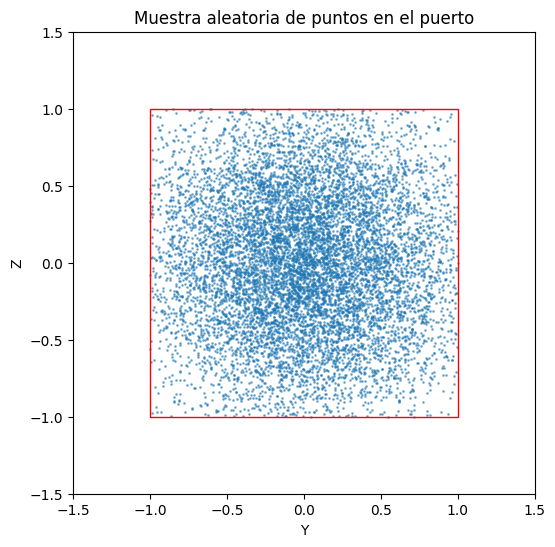

In [521]:
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter( xs[:,1], xs[:,2], s=1, alpha=0.5 )

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

ax.set_title("Muestra aleatoria de puntos en el puerto")
ax.set_xlabel("Y")
ax.set_ylabel("Z")

rect = plt.Rectangle( (-1,-1), 2, 2, linewidth=1, edgecolor='r', facecolor='none' )
ax.add_patch(rect)

## Chamber and target geometry parameters

In [522]:
BEAM_RADIUS = 0.14 #meters
TARGET_RADIUS = 0.000605 #meters 
CHAMBER_RADIUS = 1.65 #meters 
WINDOW_SIZE = 0.30 #meters

## Define geometry and focal distances

### Define and create beams based on Omega 60 

In [523]:
def get_omega_dataframe():
    """
    Constructs the master database for OMEGA-60 laser parameters.
    Calculates local coordinate systems (tangent and normal vectors) for each beam,
    ensuring compatibility with ARWEN simulation requirements.
    """
    # --- 1. Physical Configuration ---
    DEFAULT_ENERGY = 500.0     # Default beam energy [Joules]
    WAVELENGTH = 351e-9        # UV laser wavelength [351 nm]

    # OMEGA-60 port configuration: (Theta_deg, Beam_Count, Phi_Offset_deg)
    # Based on the standard 60-beam direct-drive geometry.
    omega_config = [
        (23.2, 6, 0), (47.8, 12, 15), (59.1, 12, 0),   # Northern Hemisphere
        (120.9, 12, 0), (132.2, 12, 15), (156.8, 6, 0) # Southern Hemisphere
    ]

    all_data = []
    beam_count = 1

    for theta_deg, num_beams, phi_offset in omega_config:
        # Uniform azimuthal distribution over 360°
        phis_deg = np.linspace(0, 360, num_beams, endpoint=False) + phi_offset
        
        for phi_deg in phis_deg:
            # --- 2. Geometric Coordinate Transformation ---
            # Conversion to radians for NumPy trigonometric functions
            theta_rad = np.deg2rad(theta_deg)
            phi_rad = np.deg2rad(phi_deg % 360)
            
            # Unit normal vector (beam propagation direction)
            # In a center-aligned sphere, the normal is the radial vector
            nx = np.sin(theta_rad) * np.cos(phi_rad)
            ny = np.sin(theta_rad) * np.sin(phi_rad)
            nz = np.cos(theta_rad)
            normal_u = np.array([nx, ny, nz])
            
            # Position of the port center on the chamber wall
            center = normal_u * CHAMBER_RADIUS

            # --- 3. Local Tangent Basis Calculation (t1, t2) ---
            # t1: Azimuthal direction vector (East-West alignment)
            t1 = np.array([-np.sin(phi_rad), np.cos(phi_rad), 0.0])
            
            # Singularity handling at the poles (if t1 is null)
            if np.linalg.norm(t1) < 1e-6: 
                t1 = np.array([1, 0, 0])
            t1 /= np.linalg.norm(t1)
            
            # t2: Polar direction vector (North-South alignment) via cross product
            # Completes the orthogonal right-handed coordinate system (t1, t2, normal)
            t2 = np.cross(normal_u, t1)
            t2 /= np.linalg.norm(t2)

            # --- 4. Data Record Assembly (Standardized Format) ---
            all_data.append({
                'port': f'OMEGA_J{beam_count:02d}',
                'subwindow': 0,              # Specific to OMEGA (unlike NIF quads)
                'LAT_rad': theta_rad,        # Latitude (Theta) in radians
                'LONG_rad': phi_rad,         # Longitude (Phi) in radians
                'color': 'blue' if theta_deg < 90 else 'red',
                'energy': DEFAULT_ENERGY,
                'wavelength': WAVELENGTH,
                'center': center,            # Numpy array [x, y, z]
                'normal': normal_u,          # Numpy unit vector [nx, ny, nz]
                't1': t1,                    # First tangent vector
                't2': t2,                    # Second tangent vector
                'beam_radius': BEAM_RADIUS,
                'focus': None                # Placeholder for focusing parameters
            })
            beam_count += 1

    return pd.DataFrame(all_data)

# --- EXECUTION ---
df_omega = get_omega_dataframe()

# Data verification
print(f"Generated columns: {df_omega.columns.tolist()}")
df_omega.head()

Generated columns: ['port', 'subwindow', 'LAT_rad', 'LONG_rad', 'color', 'energy', 'wavelength', 'center', 'normal', 't1', 't2', 'beam_radius', 'focus']


,port,subwindow,LAT_rad,LONG_rad,color,energy,wavelength,center,normal,t1,t2,beam_radius,focus
0,OMEGA_J01,0,0.404916,0.000000,blue,500.0,3.510000e-07,"[0.6500041508250692, 0.0, 1.5165733097711367]","[0.3939419095909511, 0.0, 0.9191353392552344]","[-0.0, 1.0, 0.0]","[-0.9191353392552345, -0.0, 0.39394190959095116]",0.14,None
1,OMEGA_J02,0,0.404916,1.047198,blue,500.0,3.510000e-07,"[0.32500207541253473, 0.5629201071798418, 1.51...","[0.1969709547954756, 0.34116370132111623, 0.91...","[-0.8660254037844386, 0.5000000000000001, 0.0]","[-0.45956766962761736, -0.7959945533110614, 0....",0.14,None
2,OMEGA_J03,0,0.404916,2.094395,blue,500.0,3.510000e-07,"[-0.3250020754125345, 0.5629201071798419, 1.51...","[-0.19697095479547547, 0.3411637013211163, 0.9...","[-0.8660254037844388, -0.49999999999999983, 0.0]","[0.459567669627617, -0.7959945533110615, 0.393...",0.14,None
3,OMEGA_J04,0,0.404916,3.141593,blue,500.0,3.510000e-07,"[-0.6500041508250692, 7.960255027404145e-17, 1...","[-0.3939419095909511, 4.8243969863055425e-17, ...","[-1.2246467991473532e-16, -1.0, 0.0]","[0.9191353392552345, -1.1256161512021395e-16, ...",0.14,None
4,OMEGA_J05,0,0.404916,4.188790,blue,500.0,3.510000e-07,"[-0.3250020754125349, -0.5629201071798416, 1.5...","[-0.19697095479547572, -0.3411637013211162, 0....","[0.8660254037844385, -0.5000000000000004, 0.0]","[0.4595676696276176, 0.7959945533110612, 0.393...",0.14,None


### Define focal point

In [524]:
def compute_focal_distance(defocus_mm=0.0):
    """
    Calculates the focal distance required to achieve a specific beam spot size.
    A positive defocus (in mm) shifts the focal point beyond the target center, 
    widening the irradiation area to improve illumination uniformity.
    """
    # Convert defocus from mm to meters and calculate the effective target radius
    # This accounts for the beam divergence/convergence at the target surface.
    effective_target_radius = TARGET_RADIUS + (defocus_mm / 1000.0) 
    
    # Using Thales' theorem (intercept theorem) to determine the focal length (f_window)
    # relative to the chamber geometry and beam aperture.
    f_window = (WINDOW_SIZE * CHAMBER_RADIUS) / (WINDOW_SIZE - effective_target_radius)
    return f_window

def compute_focus_position(port_center, f_window):
    """
    Computes the 3D coordinates of the focal point along the beam's optical axis.
    """
    # Normal unit vector pointing from the port center toward the chamber origin (0,0,0)
    propagation_vector = port_center / np.linalg.norm(port_center)
    
    # Position the focal point along the optical axis at distance f_window
    focal_point_pos = port_center - (propagation_vector * f_window)
    return focal_point_pos

def assign_beam_focus(beam_row):
    """
    Helper function to apply a standardized defocus to a specific beam port.
    A 2.0mm defocus is typically used to over-fill the target and reduce intensity peaks.
    """
    f_dist = compute_focal_distance(defocus_mm=2) 
    return compute_focus_position(beam_row["center"], f_dist)


# =====================================================
# Beam Focus Assignment Pipeline
# =====================================================

# 1. Generate the master configuration DataFrame
df_omega = get_omega_dataframe()

# 2. Compute 3D focal points for all beams using a vectorized approach (Pandas apply)
# This replaces manual loops with a more robust and scalable implementation.
df_omega['focus'] = df_omega.apply(assign_beam_focus, axis=1)

# 3. Final verification of the focus coordinates
df_omega.head()

,port,subwindow,LAT_rad,LONG_rad,color,energy,wavelength,center,normal,t1,t2,beam_radius,focus
0,OMEGA_J01,0,0.404916,0.000000,blue,500.0,3.510000e-07,"[0.6500041508250692, 0.0, 1.5165733097711367]","[0.3939419095909511, 0.0, 0.9191353392552344]","[-0.0, 1.0, 0.0]","[-0.9191353392552345, -0.0, 0.39394190959095116]",0.14,"[-0.005693642505419816, 0.0, -0.01328426325914..."
1,OMEGA_J02,0,0.404916,1.047198,blue,500.0,3.510000e-07,"[0.32500207541253473, 0.5629201071798418, 1.51...","[0.1969709547954756, 0.34116370132111623, 0.91...","[-0.8660254037844386, 0.5000000000000001, 0.0]","[-0.45956766962761736, -0.7959945533110614, 0....",0.14,"[-0.002846821252709908, -0.004930839049760438,..."
2,OMEGA_J03,0,0.404916,2.094395,blue,500.0,3.510000e-07,"[-0.3250020754125345, 0.5629201071798419, 1.51...","[-0.19697095479547547, 0.3411637013211163, 0.9...","[-0.8660254037844388, -0.49999999999999983, 0.0]","[0.459567669627617, -0.7959945533110615, 0.393...",0.14,"[0.002846821252709908, -0.004930839049760438, ..."
3,OMEGA_J04,0,0.404916,3.141593,blue,500.0,3.510000e-07,"[-0.6500041508250692, 7.960255027404145e-17, 1...","[-0.3939419095909511, 4.8243969863055425e-17, ...","[-1.2246467991473532e-16, -1.0, 0.0]","[0.9191353392552345, -1.1256161512021395e-16, ...",0.14,"[0.005693642505419816, -6.972701069751618e-19,..."
4,OMEGA_J05,0,0.404916,4.188790,blue,500.0,3.510000e-07,"[-0.3250020754125349, -0.5629201071798416, 1.5...","[-0.19697095479547572, -0.3411637013211162, 0....","[0.8660254037844385, -0.5000000000000004, 0.0]","[0.4595676696276176, 0.7959945533110612, 0.393...",0.14,"[0.0028468212527099634, 0.004930839049760438, ..."


### Creates data frame of complete beam geometry and data

In [525]:
# 1. We use the 'df_omega' DataFrame we just created and filled with focus data
# No need to create a new DataFrame from a list anymore!

# 2. Define OMEGA beam dimensions
# For OMEGA, the beam diameter is typically 28cm (0.28m)
df_omega['l1'] = 0.28
df_omega['l2'] = 0.28

# 3. Function to split vector columns [x, y, z] into three separate columns
def expand_vector_column(df, column_name):
    # Create a temporary DataFrame from the list of coordinates
    # .tolist() is used because these columns contain numpy arrays
    temp = pd.DataFrame(df[column_name].tolist(), index=df.index)
    temp.columns = [f'{column_name}_x', f'{column_name}_y', f'{column_name}_z']
    return temp

# 4. Expand all geometric vector columns
# This "flattens" the data so ARWEN can read it easily
df_centers = expand_vector_column(df_omega, 'center')
df_t1      = expand_vector_column(df_omega, 't1')
df_t2      = expand_vector_column(df_omega, 't2')
df_normal  = expand_vector_column(df_omega, 'normal')
df_focus   = expand_vector_column(df_omega, 'focus')

# 5. Assemble the final Master Table
# We select the metadata and join it with the expanded coordinates
data_columns = ['port', 'subwindow', 'LAT_rad', 'LONG_rad', 'color', 'energy', 'wavelength', 'l1', 'l2']

df_omega_final = pd.concat([
    df_omega[data_columns],
    df_centers, 
    df_t1, 
    df_t2, 
    df_normal, 
    df_focus
], axis=1)

# 6. Aesthetic renaming for clarity
df_omega_final = df_omega_final.rename(columns={'LAT_rad': 'LAT', 'LONG_rad': 'LONG'})

# 7. Display the result
print(f"Final OMEGA-60 table generated with {len(df_omega_final)} rows.")
df_omega_final.head(10)

Final OMEGA-60 table generated with 60 rows.


,port,subwindow,LAT,LONG,color,energy,wavelength,l1,l2,center_x,...,t1_z,t2_x,t2_y,t2_z,normal_x,normal_y,normal_z,focus_x,focus_y,focus_z
0,OMEGA_J01,0,0.404916,0.000000,blue,500.0,3.510000e-07,0.28,0.28,0.650004,...,0.0,-0.919135,-0.000000e+00,0.393942,0.393942,0.000000e+00,0.919135,-0.005694,0.000000e+00,-0.013284
1,OMEGA_J02,0,0.404916,1.047198,blue,500.0,3.510000e-07,0.28,0.28,0.325002,...,0.0,-0.459568,-7.959946e-01,0.393942,0.196971,3.411637e-01,0.919135,-0.002847,-4.930839e-03,-0.013284
2,OMEGA_J03,0,0.404916,2.094395,blue,500.0,3.510000e-07,0.28,0.28,-0.325002,...,0.0,0.459568,-7.959946e-01,0.393942,-0.196971,3.411637e-01,0.919135,0.002847,-4.930839e-03,-0.013284
3,OMEGA_J04,0,0.404916,3.141593,blue,500.0,3.510000e-07,0.28,0.28,-0.650004,...,0.0,0.919135,-1.125616e-16,0.393942,-0.393942,4.824397e-17,0.919135,0.005694,-6.972701e-19,-0.013284
4,OMEGA_J05,0,0.404916,4.188790,blue,500.0,3.510000e-07,0.28,0.28,-0.325002,...,0.0,0.459568,7.959946e-01,0.393942,-0.196971,-3.411637e-01,0.919135,0.002847,4.930839e-03,-0.013284
5,OMEGA_J06,0,0.404916,5.235988,blue,500.0,3.510000e-07,0.28,0.28,0.325002,...,0.0,-0.459568,7.959946e-01,0.393942,0.196971,-3.411637e-01,0.919135,-0.002847,4.930839e-03,-0.013284
6,OMEGA_J07,0,0.834267,0.261799,blue,500.0,3.510000e-07,0.28,0.28,1.180678,...,0.0,-0.648832,-1.738541e-01,0.740805,0.715562,1.917343e-01,0.671721,-0.010342,-2.771136e-03,-0.009708
7,OMEGA_J08,0,0.834267,0.785398,blue,500.0,3.510000e-07,0.28,0.28,0.864316,...,0.0,-0.474978,-4.749782e-01,0.740805,0.523828,5.238280e-01,0.671721,-0.007571,-7.570886e-03,-0.009708
8,OMEGA_J09,0,0.834267,1.308997,blue,500.0,3.510000e-07,0.28,0.28,0.316362,...,0.0,-0.173854,-6.488323e-01,0.740805,0.191734,7.155623e-01,0.671721,-0.002771,-1.034202e-02,-0.009708
9,OMEGA_J10,0,0.834267,1.832596,blue,500.0,3.510000e-07,0.28,0.28,-0.316362,...,0.0,0.173854,-6.488323e-01,0.740805,-0.191734,7.155623e-01,0.671721,0.002771,-1.034202e-02,-0.009708


## Impacts of the laser beams from window to a target sphere

### Calculates hits on sphere

In [526]:
def hit_sphere( x, u, radius, center=np.array([0.,0.,0.,]), ):
  
  dx = x - center

  # Coeficientes de la ecuación cuadrática
  A = u[0]**2 + u[1]**2 + u[2]**2 
  B = 2*(dx[0]*u[0] + dx[1]*u[1] + dx[2]*u[2])
  C = dx[0]**2 + dx[1]**2 + dx[2]**2 - radius**2

  disc = B*B - 4*A*C

  # Calcular puntos de intersección (si existen)
  if disc < 0:
    return []
  elif disc == 0:
    return [ -0.5 * B / A ] 
  else:
    disc = np.sqrt(disc)
    l1 = 0.5 * (-B + disc) / A
    l2 = 0.5 * (-B - disc) / A
    return [ l1, l2, ]

### Collects impact information

In [527]:
def ray_hit_on_sphere( x, u, radius, center=np.array([0.,0.,0.,]), ):

  ls = hit_sphere( x, u, radius=radius, center=center, )
  
  if len(ls) == 0:
    return -1.
  elif len(ls) == 1:
    if ls[0] < 0:
      return -1.
    else:
      return ls[0]
  else:
    l1, l2 = ls
    if l1 < 0 and l2 < 0:
      return -1.
    elif l1 > 0 and l2 > 0:
      return min(l1, l2)
    else:
      return max(l1, l2)
    

  
def ray_hit( x, u, radius, center=np.array([0.,0.,0.,]), ):
  l = ray_hit_on_sphere( x, u, radius=radius, center=center, ) # Longitud de impacto
  xsph = x + l * u 
  n = ( xsph - center ) / np.linalg.norm( xsph - center )
  cs = np.dot( n, u) / np.linalg.norm(u)
  return [ x, u, l, xsph, cs, cart_to_sph( xsph[0], xsph[1], xsph[2] ), n, ] # Devuelve r, theta, phi del punto

### Validation of hits on sphere

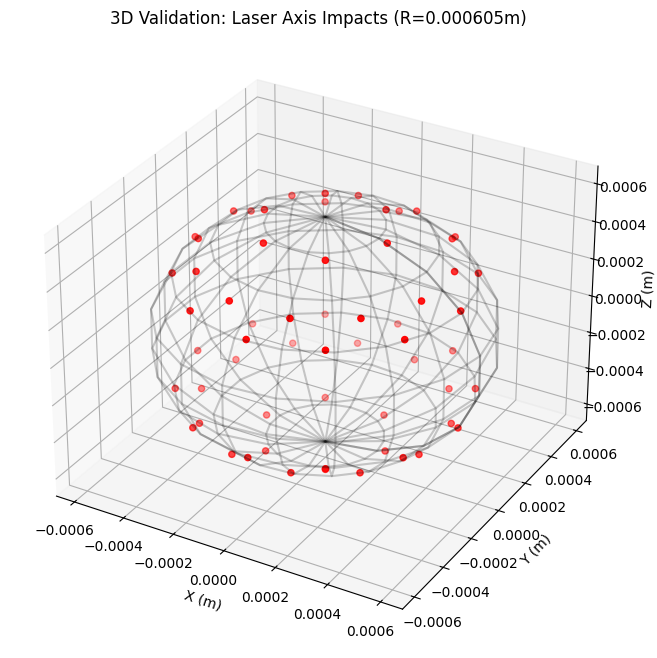

In [528]:
# Initialize a list to store the coordinates of successful impacts
hits = []

# Iterate through each laser beam in the dataset
for i, row in df_omega.iterrows():
    # 1. Retrieve the starting position (port center) and the target focal point
    x = row["center"]
    focus = row["focus"]
    
    # 2. Compute the normalized direction vector (unit vector) from port to focus
    u = focus - x
    u = u / np.linalg.norm(u)

    # 3. Perform the ray-sphere intersection test against the target
    # Returns a list of distances (l) where the ray hits the sphere
    res_hits = hit_sphere(x, u, radius=TARGET_RADIUS)
    
    # 4. Check if an impact was detected (if the list is not empty)
    if len(res_hits) > 0:
        # We take the first intersection distance (l1)
        l_impact = res_hits[0] 
        
        # 5. Calculate the exact 3D coordinates of the impact point on the target surface
        # Formula: Impact_Point = Origin + distance * direction
        impact_point = x + l_impact * u
        hits.append(impact_point)

# --- Visualization Section ---

# If impacts were found, proceed to 3D plotting
if len(hits) > 0:
    hits = np.array(hits)

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the impact points in red
    ax.scatter(hits[:,0], hits[:,1], hits[:,2], s=20, c='red', label='Laser Impacts')
    
    # Create a wireframe sphere to represent the target (fuel pellet)
    u_sph, v_sph = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    x_sph = TARGET_RADIUS * np.cos(u_sph)*np.sin(v_sph)
    y_sph = TARGET_RADIUS * np.sin(u_sph)*np.sin(v_sph)
    z_sph = TARGET_RADIUS * np.cos(v_sph)
    ax.plot_wireframe(x_sph, y_sph, z_sph, color="black", alpha=0.2)

    ax.set_title(f"3D Validation: Laser Axis Impacts (R={TARGET_RADIUS}m)")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_zlabel("Z (m)")
    plt.show()
else:
    # Diagnostic message if no beams hit the target
    print("Error: No impacts detected. Check focal distances, target radius, or beam orientations.")

## Simulation of impacts for 1 window

### Creates beam sample

In [529]:
def beam_sample(beam, num_samples):
    # 1. Reconstrucción de vectores a partir de las columnas individuales (x, y, z)
    t1 = np.array([beam['t1_x'], beam['t1_y'], beam['t1_z']])
    t2 = np.array([beam['t2_x'], beam['t2_y'], beam['t2_z']])
    center = np.array([beam['center_x'], beam['center_y'], beam['center_z']])
    
    l1 = beam['l1']
    l2 = beam['l2']
    
    # 2. Definición de la distribución NORMAL (Gaussiana)
    # loc=0.0: Centrada en el eje del haz
    # scale=0.5: Desviación estándar (concentra el 95% de la energía en el área central)
    # IMPORTANTE: La lambda genera datos numéricos mediante .rvs para evitar errores de tipo
    dist_gauss = lambda n: sp.stats.norm(loc=0.0, scale=0.5).rvs(size=(n, 2))
    
    return sample_window(t1, t2, l1=l1, l2=l2, center=center, num_points=num_samples, dist=dist_gauss)

### Creates hit of beam on sphere

In [530]:
def beam_hit(beam, num_samples, radius, center_target):
    data = []
    t1, t2 = beam['t1'], beam['t2']
    center, focus = beam['center'], beam['focus']
    l1, l2 = beam['l1'], beam['l2']
    
    dist_gauss = lambda n: sp.stats.norm(loc=0.0, scale=0.15).rvs(size=(n, 2))
    ray_origins = sample_window(t1, t2, l1=l1, l2=l2, center=center, num_points=num_samples, dist=dist_gauss)
    
    for i in range(num_samples):
        x_ray = ray_origins[i]
        u_ray = (focus - x_ray) / np.linalg.norm(focus - x_ray)
        
        res = hit_sphere(x_ray, u_ray, radius=radius, center=center_target)
        
        if len(res) > 0:
            l_val = res[0]
            xsph_val = x_ray + l_val * u_ray
            
            # --- C'est ici qu'on définit les noms des colonnes ---
            data.append({
                'port': beam['port'],
                'x': x_ray,      # Position de départ (vecteur)
                'u': u_ray,      # Direction (vecteur)
                'l': l_val,      # Distance d'impact (scalaire)
                'xsph': xsph_val # Point d'impact sur la bille (vecteur)
            })
            
    return pd.DataFrame(data)

### Simulation parameters

In [531]:
# Test on the first beam of your Omega60 configuration
impacts_1window = beam_hit(
    df_omega.iloc[0], 
    num_samples=10000, 
    radius=TARGET_RADIUS, 
    center_target=np.array([0.0, 0.0, 0.0])
)

print(f"Impacts effectifs : {len(impacts_1window)} sur 10000 rayons lancés.")

Impacts effectifs : 9957 sur 10000 rayons lancés.


### Impacts data

In [532]:
impacts_1window.head()

,port,x,u,l,xsph
0,OMEGA_J01,"[0.6490363821126522, -0.03516308253938777, 1.5...","[-0.39327264763992603, 0.02112119201729454, -0...",1.650897,"[-0.0002163323171175957, -0.000294165691206001..."
1,OMEGA_J01,"[0.6387889251096693, -0.02979426981470549, 1.5...","[-0.387131406075547, 0.01789698922197987, -0.9...",1.650851,"[-0.00030719745706109247, -0.00024901402330673..."
2,OMEGA_J01,"[0.6549914303608804, -0.017248108863634485, 1....","[-0.39691483750597845, 0.010362017560339687, -...",1.650683,"[-0.00018927791949496786, -0.00014369914427047..."
3,OMEGA_J01,"[0.6668118003998258, -0.007698671730835111, 1....","[-0.4040112085065574, 0.004625017838418006, -0...",1.650699,"[-8.919130301554556e-05, -6.415833580825699e-0..."
4,OMEGA_J01,"[0.6550600866105221, 0.011829562001614852, 1.5...","[-0.39696731215164566, -0.007106958651592105, ...",1.650646,"[-0.00019236789350829397, 9.849005195413339e-0..."


### Impacts of data organized

In [533]:
def expand_impacts(df_impacts):
    """
    Expands vector columns (lists/arrays) into individual X, Y, Z columns.
    Renamed and adapted for the Omega-60 simulation.
    """
    # 1. Create a copy to avoid modifying the original data
    df = df_impacts.copy()

    # 2. Internal helper to split vector columns [x, y, z] into separate columns
    def split_vector_col(df_in, col_name, new_names):
        # Converts the list/array in the cell into a temporary DataFrame
        temp = pd.DataFrame(df_in[col_name].tolist(), index=df_in.index)
        temp.columns = new_names
        return temp

    # 3. Expand key vector columns
    # 'xsph' -> Target impact point coordinates
    df_xsph = split_vector_col(df, 'xsph', ['xsph_x', 'xsph_y', 'xsph_z'])
    
    # 'u' -> Ray direction vector
    df_u = split_vector_col(df, 'u', ['u_x', 'u_y', 'u_z'])

    # 4. Concatenate everything into a final structured DataFrame
    # Note: 'l' is the distance, 'port' is the beam ID
    # If you have 'subwindow' or 'cs', include them in the list below
    existing_scalars = ['port', 'l'] 
    
    # Check which scalar columns actually exist to avoid errors
    cols_to_keep = [c for c in existing_scalars if c in df.columns]
    
    df_final = pd.concat([
        df[cols_to_keep],
        df_xsph,
        df_u
    ], axis=1)

    return df_final
df_impacts = beam_hit(df_omega.iloc[0], num_samples=10000, radius=TARGET_RADIUS, center_target=np.array([0.0, 0.0, 0.0]))
# --- Execution ---
# Transform the technical dataframe into a human-readable table
impact_1window_view = expand_impacts(df_impacts)

# Display the first 10 rows
impact_1window_view.head(10)

,port,l,xsph_x,xsph_y,xsph_z,u_x,u_y,u_z
0,OMEGA_J01,1.651170,-0.000541,-0.000116,-0.000244,-0.367462,0.008268,-0.930002
1,OMEGA_J01,1.651228,-0.000448,-0.000314,-0.000259,-0.373480,0.022350,-0.927369
2,OMEGA_J01,1.650803,-0.000423,0.000093,-0.000423,-0.379186,-0.006675,-0.925297
3,OMEGA_J01,1.650736,-0.000064,-0.000085,-0.000595,-0.405526,0.006155,-0.914063
4,OMEGA_J01,1.650824,-0.000173,0.000249,-0.000523,-0.396971,-0.017910,-0.917657
5,OMEGA_J01,1.650688,-0.000366,-0.000047,-0.000479,-0.384130,0.003389,-0.923273
6,OMEGA_J01,1.650850,-0.000457,-0.000045,-0.000394,-0.376379,0.003201,-0.926460
7,OMEGA_J01,1.650705,-0.000074,-0.000026,-0.000600,-0.405063,0.001846,-0.914287
8,OMEGA_J01,1.650670,-0.000180,-0.000125,-0.000564,-0.397672,0.009049,-0.917483
9,OMEGA_J01,1.650626,-0.000306,0.000014,-0.000522,-0.388888,-0.001012,-0.921284


### 

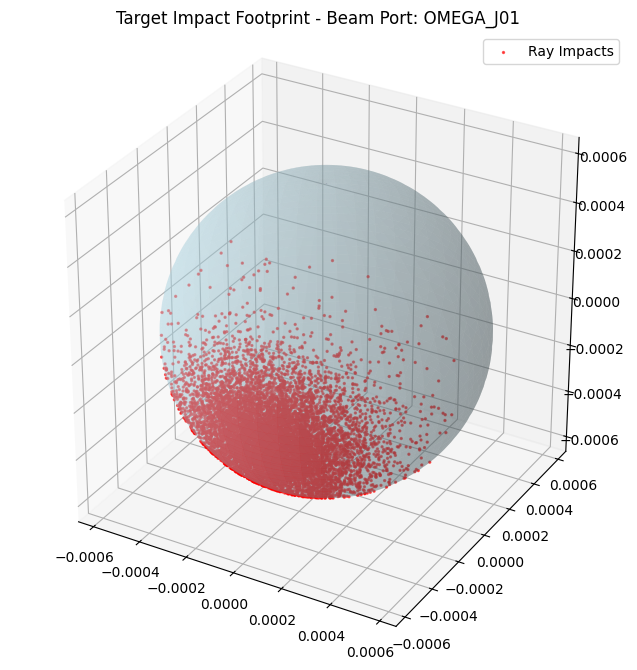

In [534]:
def plot_impact_footprint(impact_df, sphere_radius=TARGET_RADIUS):
    """
    Plots the 3D footprint of a single beam's rays on the target sphere.
    """
    # 1. Create 3D figure and axis
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 2. Draw the SOLID colored sphere (target)
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x_sphere = sphere_radius * np.outer(np.cos(u), np.sin(v))
    y_sphere = sphere_radius * np.outer(np.sin(u), np.sin(v))
    z_sphere = sphere_radius * np.outer(np.ones_like(u), np.cos(v))
    
    # Surface plot with transparency to see impacts on both sides
    ax.plot_surface(x_sphere, y_sphere, z_sphere, 
                    color='lightblue', 
                    alpha=0.3,       # Transparency
                    linewidth=0, 
                    antialiased=True)

    # 3. Plot the impact points from the expanded DataFrame
    # Using the columns we just created: xsph_x, xsph_y, xsph_z
    xs = impact_df['xsph_x']
    ys = impact_df['xsph_y']
    zs = impact_df['xsph_z']
    
    # Scatter plot of the 10,000 rays (or as many as hit the target)
    ax.scatter(xs, ys, zs, color='red', s=2, alpha=0.6, label='Ray Impacts')

    # 4. Aesthetic configuration
    beam_id = impact_df['port'].iloc[0] if not impact_df.empty else "N/A"
    ax.set_title(f"Target Impact Footprint - Beam Port: {beam_id}")
    
    # Set axis limits to fit the sphere
    limit = sphere_radius * 1.1
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    
    # Set 1:1:1 aspect ratio so it looks like a sphere, not an egg
    ax.set_box_aspect([1, 1, 1])
    
    plt.legend()
    plt.show()

# --- Execution ---
# We use the expanded view we generated in the previous step
plot_impact_footprint(impact_1window_view, sphere_radius=TARGET_RADIUS)

### Pyvista plotter of the impacts in one subwindow

## Simulation of hits from windows chosen by probability